In [1]:
from scripts.preflight import preflight_check
preflight_check()

I0000 00:00:1783298784.950077  104012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783298785.090891  104012 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783298785.903806  104012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
Python version: 3.12.13 (main, Jun 23 2026, 15:18:55) [Clang 22.1.3 ]
NumPy version: 2.5.0
TensorFlow ver

{'gpu_available': True,
 'gpu_count': 1,
 'devices': ["PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')"],
 'compute_ok': True}

# **MODEL COMPUTER VISION DALAM MEMILAH JENIS SAMPAH**
**Organik • Anorganik • B3 (Bahan Berbahaya & Beracun)**

**Studi Kasus 2 — Lingkungan: Mendukung Aksi Iklim Lokal**

> **Versi revisi**: menambahkan *oversampling* untuk mengatasi imbalance, dan melatih model **EfficientNetB0**.

## **1. MERAPIKAN DAN MAPPING LABEL BARU DATASET**

---

Dataset sebelumnya sangat berantakan dikarenakan menggunakan 3 dataset dari kaggle yang telah disatukan.
Jadi rapikan dataset sekaligus lakukan mapping label baru yaitu pada folder "Dataset - Final":

1. ORGANIK
2. ANORGANIK
3. B3

## **2. IMPORT LIBRARY**

In [2]:
# Manipulasi data
import os # Untuk membaca folder, membuat folder, dan mengakses file.
import random # Untuk proses pembagian dataset agar data diacak terlebih dahulu.
import shutil # Untuk menyalin gambar ketika proses dataset splitting.
from concurrent.futures import ThreadPoolExecutor # Untuk mempercepat validasi/perbaikan gambar secara paralel.

import warnings
warnings.filterwarnings("ignore")

# Split data
import splitfolders

# Visualisasi
import matplotlib.pyplot as plt # Untuk menampilkan grafik hasil training dan visualisasi dataset.
import numpy as np # Untuk manipulasi array dan hasil prediksi model.
import pandas as pd # Untuk menyusun tabel perbandingan antar model.

# Image Processing
from PIL import Image # Untuk membuka gambar dan mendeteksi file yang rusak saat proses data cleaning.

# TensorFlow. Framework utama yang digunakan untuk membangun model.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2 # Buat regularisasi dense layer, biar gak overfit
from tensorflow.keras.optimizers import Adam

# Arsitektur pretrained yang digunakan
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

from tensorflow.keras.callbacks import EarlyStopping # Menghentikan training apabila model sudah tidak ada peningkatan.
from tensorflow.keras.callbacks import ModelCheckpoint # Menyimpan model terbaik selama proses training.
from tensorflow.keras.callbacks import ReduceLROnPlateau # Menurunkan learning rate secara otomatis ketika model mulai berhenti berkembang
from tensorflow.keras.callbacks import CSVLogger # Logging proses training

# Evaluasi
from sklearn.metrics import classification_report # Menampilkan nilai Precision, Recall, dan F1-Score.
from sklearn.metrics import confusion_matrix # Menampilkan jumlah prediksi benar dan salah pada setiap kelas


****
## **3. REPRODUCIBILITY**
Agar hasil split tidak berubah

In [3]:
state = 42
random.seed(state)
np.random.seed(state)
tf.random.set_seed(state)

dataset_path = "/srv/LKS/datasets/final"
os.environ['TF_DATA_RAM_BUDGET'] = '2147483648'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

## 4. **DATA CLEANING**
Sebelum dataset digunakan untuk proses pelatihan model, dilakukan proses data cleaning untuk memastikan seluruh gambar dapat dibaca dengan baik. File gambar yang rusak (corrupt) atau tidak valid akan dihapus agar tidak menyebabkan error saat proses training.

In [4]:
valid_extension = (".jpg", ".jpeg", ".png")
cleaned_path = os.path.join(dataset_path, ".cleaned")

image_totals = 0
deleted_images = 0

def valid_images(path):
    try:
        if os.path.getsize(path) == 0:
            return False
        with Image.open(path) as foto:
            foto.load()
        return True
    except Exception:
        return False

if os.path.exists(cleaned_path):
    print("Dataset sudah pernah dibersihkan sebelumnya, proses cleaning di-skip.")
    print("Hapus file penanda ini kalau mau cleaning ulang:", cleaned_path)
else:
    all_path = []
    for cls in os.listdir(dataset_path):
        class_folder = os.path.join(dataset_path, cls)
        if not os.path.isdir(class_folder):
            continue
        for file in os.listdir(class_folder):
            path = os.path.join(class_folder, file)
            image_totals += 1
            if not file.lower().endswith(valid_extension):
                os.remove(path)
                deleted_images += 1
            else:
                all_path.append(path)

    def check_and_delete(path):
        if not valid_images(path):
            os.remove(path)
            return 1
        return 0

    with ThreadPoolExecutor(max_workers=16) as executor:
        hasil = list(executor.map(check_and_delete, all_path))
    deleted_images += sum(hasil)

    with open(cleaned_path, "w") as f:
        f.write("cleaned")

    print(f"Total gambar diperiksa : {image_totals}")
    print(f"Gambar dihapus         : {deleted_images}")

Total gambar diperiksa : 31940
Gambar dihapus         : 0


## **5. DATA SPLITTING**
Dataset dibagi menjadi tiga bagian yaitu training, validation, dan testing dengan rasio 80%, 10%, dan 10%.

Pembagian dilakukan secara acak agar distribusi data lebih merata pada setiap kelas.

> Catatan: split dilakukan **sebelum** oversampling. Oversampling hanya diterapkan pada data **training**, val & test tetap memakai distribusi asli supaya evaluasi tetap jujur/tidak bias.

In [5]:
splitfolders.ratio(
    input=dataset_path,
    output="dataset_split",
    seed=state,
    ratio=(0.8, 0.1, 0.1)
)

Copying files: 31940 files [00:01, 20158.47 files/s]


## **6. PERBAIKAN DATA**

Agar proses training berjalan lebih bersih tanpa menampilkan warning `incorrect sRGB profile`.

In [6]:
folder = "dataset_split"
marker_path_split = os.path.join(folder, ".fixed")
images_fixed = 0
images_skip = 0
images_deletes_split = 0

def fix_image(path):
    """Skip save ulang kalau gambar sudah RGB DAN tidak ada ICC profile bermasalah."""
    try:
        if os.path.getsize(path) == 0:
            raise ValueError("File kosong (0 byte)")

        image = Image.open(path)
        image.load()  # paksa decode penuh

        has_icc = "icc_profile" in image.info

        if image.mode == "RGB" and not has_icc:
            return "dilewati"

        image = image.convert("RGB")
        # buang ICC profile waktu save ulang
        image.save(path, icc_profile=None)
        return "diperbaiki"
    except Exception:
        os.remove(path)
        return "dihapus"

if os.path.exists(marker_path_split):
    print("Dataset hasil split sudah pernah diperbaiki sebelumnya, proses di-skip.")
    print("Hapus file penanda ini kalau mau perbaikan ulang:", marker_path_split)
else:
    all_path = []
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                all_path.append(os.path.join(root, file))

    with ThreadPoolExecutor(max_workers=16) as executor:
        hasil = list(executor.map(fix_image, all_path))

    images_fixed = hasil.count("diperbaiki")
    images_skip = hasil.count("dilewati")
    images_deletes_split = hasil.count("dihapus")

    with open(marker_path_split, "w") as f:
        f.write("fixed")

    print(f"Gambar diperbaiki (convert ke RGB) : {images_fixed}")
    print(f"Gambar dilewati (sudah RGB)        : {images_skip}")
    print(f"Gambar dihapus (corrupt)           : {images_deletes_split}")


Gambar diperbaiki (convert ke RGB) : 1292
Gambar dilewati (sudah RGB)        : 30648
Gambar dihapus (corrupt)           : 0


## **7. DATA LOADING**

Setelah Data Splitting, memuat seluruh dataset ke dalam TensorFlow.

> Gambar dimuat dalam skala piksel **0–255 (raw)**. Normalisasi khusus arsitektur EfficientNetB0 dilakukan **di dalam model** (lihat bagian 12), bukan di pipeline data.


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Memuat dataset training
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=state,
    label_mode="categorical"
)

class_names = train_dataset.class_names

# Memuat dataset validasi
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="categorical"
)

# Memuat dataset testing
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="categorical"
)

Found 25552 files belonging to 3 classes.
Found 3193 files belonging to 3 classes.
Found 3195 files belonging to 3 classes.


## **8. EXPLORATORY DATA ANALYSIS (EDA)**

Exploratory Data Analysis (EDA) untuk memahami karakteristik dataset

### 8.1 Daftar Nama Kelas

In [8]:
print("Daftar kelas:")
for kelas in class_names:
    print("-", kelas)

Daftar kelas:
- anorganik
- b3
- organik


### 8.2 Sample Gambar

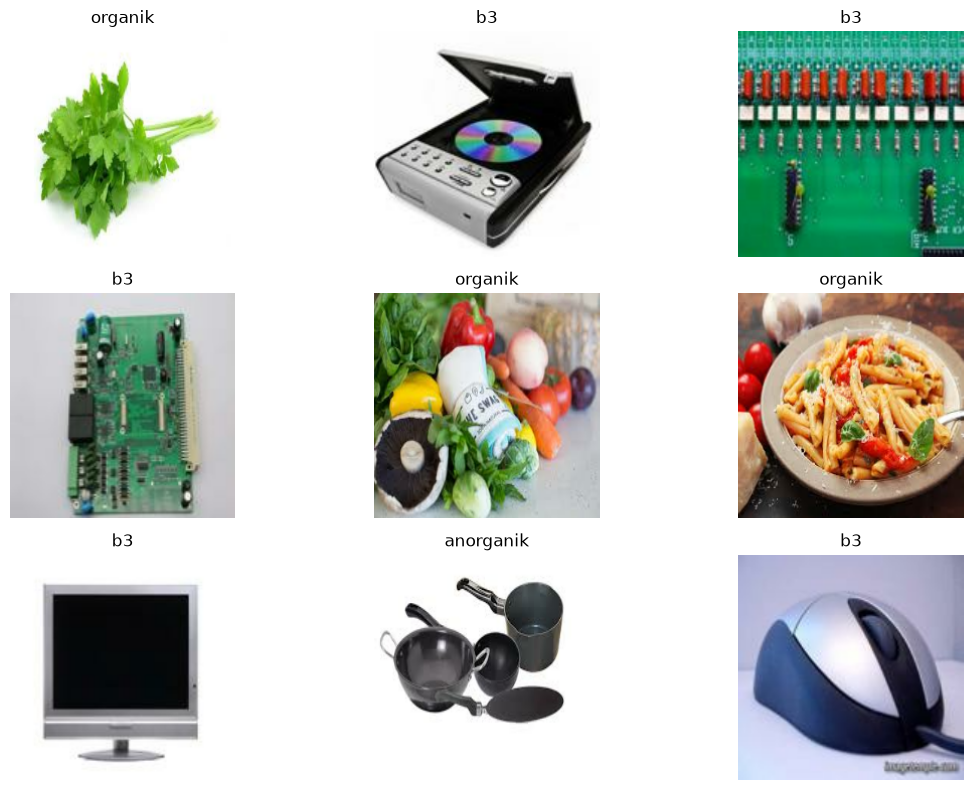

In [9]:
plt.figure(figsize=(12,8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        if len(labels.shape) == 1:
            label = int(labels[i])
        else:
            label = tf.argmax(labels[i]).numpy()

        plt.title(class_names[label])
        plt.axis("off")

plt.tight_layout()
plt.show()


### 8.3 Total Jumlah Data

In [10]:
train_path = "dataset_split/train"
jumlah_data = {}

for kelas in class_names:
    folder = os.path.join(train_path, kelas)
    jumlah_data[kelas] = len(os.listdir(folder))

print("Jumlah Data Training")
for kelas, jumlah in jumlah_data.items():
    print(f"{kelas} : {jumlah}")


Jumlah Data Training
anorganik : 9720
b3 : 4132
organik : 11700


### 8.4 Visualisasi Distribusi Dataset

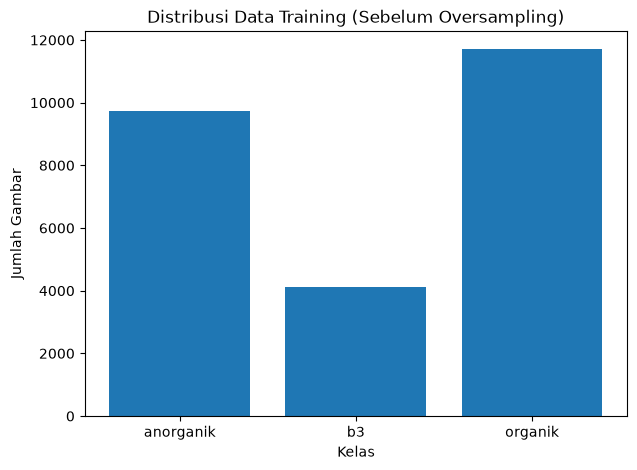

In [11]:
plt.figure(figsize=(7,5))
plt.bar(
    jumlah_data.keys(),
    jumlah_data.values()
)

plt.title("Distribusi Data Training (Sebelum Oversampling)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.show()

## **9. DATASET PIPELINE (CACHE & PREFETCH)**

Data belum dinormalisasi di sini (masih 0–255) karena normalisasi dilakukan per-model pada bagian 12. Di sini hanya dilakukan `cache()` dan `prefetch()` supaya training lebih cepat.

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

## **10. DATA AUGMENTATION**

Data augmentation untuk meningkatkan variasi training jadi model mampu untuk generalisasi pada data baru.

In [13]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
], name="augmentation")

## **11. MENGATASI DATA IMBALANCE: OVERSAMPLING**

Sebelumnya dataset yang imbalance ditangani dengan `class_weight`. Sekarang ditambahkan **oversampling** langsung pada `tf.data.Dataset` training, supaya setiap batch berisi jumlah gambar per kelas yang **seimbang** (kelas minoritas diambil ulang/di-resample lebih sering).

Caranya:
1. Pecah dataset training jadi satu `tf.data.Dataset` per kelas.
2. Set masing-masing dataset kelas jadi `repeat()` (di-ulang tanpa batas).
3. Gabungkan dengan `tf.data.Dataset.sample_from_datasets`, beri bobot yang sama tiap kelas → tiap kelas punya peluang muncul yang sama di setiap sample.
4. Augmentasi diterapkan setelah resampling supaya variasi gambar kelas minoritas yang diulang-ulang tidak identik persis.

In [14]:
def buat_dataset_per_kelas(nama_kelas):
    ds = tf.keras.utils.image_dataset_from_directory(
        "dataset_split/train",
        image_size=IMG_SIZE,
        batch_size=1,
        shuffle=True,
        seed=state,
        label_mode="categorical",
    )
    idx_kelas = class_names.index(nama_kelas)
    ds = ds.unbatch()
    ds = ds.filter(lambda x, y: tf.argmax(y) == idx_kelas)
    return ds.repeat()

print("Menyiapkan dataset per kelas untuk oversampling...")
dataset_per_kelas = [buat_dataset_per_kelas(k) for k in class_names]

train_dataset_balanced = tf.data.Dataset.sample_from_datasets(
    dataset_per_kelas,
    weights=[1.0 / len(class_names)] * len(class_names),
    seed=state
)

# TARGET DIRUNTUNKAN: bukan jumlah_maks (11700), tapi target moderat per kelas
target_per_kelas = 8500  # bukan max(jumlah_data.values())
steps_per_epoch = (target_per_kelas * len(class_names)) // BATCH_SIZE

train_dataset_balanced = (
    train_dataset_balanced
    .batch(BATCH_SIZE)
    .map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print(f"Steps per epoch (setelah oversampling): {steps_per_epoch}")

Menyiapkan dataset per kelas untuk oversampling...
Found 25552 files belonging to 3 classes.
Found 25552 files belonging to 3 classes.
Found 25552 files belonging to 3 classes.
Steps per epoch (setelah oversampling): 796


### 11.1 Verifikasi Distribusi Setelah Oversampling

Distribusi label pada satu epoch setelah oversampling:
anorganik : 8411
b3 : 8530
organik : 8531


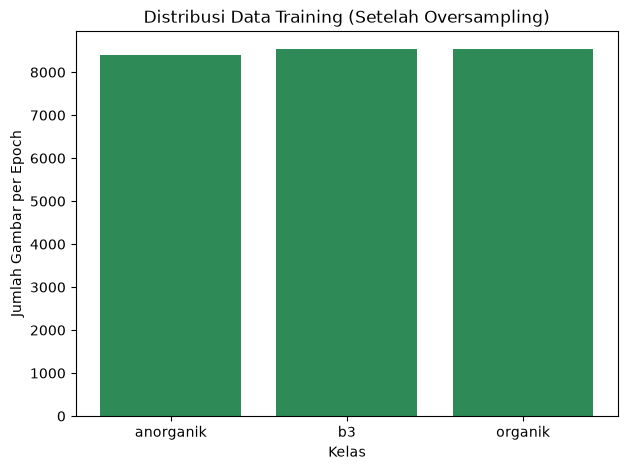

In [15]:
cek_label = []
for _, y in train_dataset_balanced.take(steps_per_epoch):
    cek_label.extend(tf.argmax(y, axis=1).numpy())

cek_label = np.array(cek_label)
distribusi_baru = {kelas: int((cek_label == i).sum()) for i, kelas in enumerate(class_names)}

print("Distribusi label pada satu epoch setelah oversampling:")
for k, v in distribusi_baru.items():
    print(f"{k} : {v}")

plt.figure(figsize=(7,5))
plt.bar(distribusi_baru.keys(), distribusi_baru.values(), color="seagreen")
plt.title("Distribusi Data Training (Setelah Oversampling)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar per Epoch")
plt.show()

## **12. BANGUN MODEL**

Arsitektur yang digunakan:

- **EfficientNetB0**: punya rasio akurasi/parameter yang baik (compound scaling), sering unggul di dataset gambar sampah/objek sehari-hari karena representasi fitur yang lebih kaya.


### 12.1 Fungsi Pembangun Model (dipakai ulang untuk kedua arsitektur)

In [16]:
def bangun_model(base_model_class, preprocess_fn, nama_model, jumlah_kelas=3):
    """Membangun arsitektur transfer learning EfficientNetB0.
    Preprocessing khusus arsitektur dilakukan di dalam model lewat
    Lambda, sehingga dataset mentah (0-255) bisa dipakai langsung.
    """
    base_model = base_model_class(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = layers.Lambda(preprocess_fn, name="preprocessing")(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(jumlah_kelas, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=nama_model)
    return model, base_model


### 12.2 Membangun Model — EfficientNetB0

In [17]:
model_efficientnet, base_efficientnet = bangun_model(
    EfficientNetB0, efficientnet_preprocess, "EfficientNetB0_Sampah"
)


### 12.3 Ringkasan Model

In [18]:
model_efficientnet.summary()

Model: "EfficientNetB0_Sampah"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Lambda)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,840,614 (18.47 MB)

 Trainable params: 789,507 (3.01 MB)

 Non-trainable params: 4,051,107 (15.45 MB)

## **13. COMPILE MODEL**

Karena data sudah seimbang lewat oversampling, cukup pakai `categorical_crossentropy` biasa (tidak perlu focal loss lagi).

In [19]:
model_efficientnet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


## **14. CALLBACK**

In [20]:
def buat_callbacks(nama_model):
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ModelCheckpoint(f"best_{nama_model}.keras", save_best_only=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7),
        CSVLogger(f"training_log_{nama_model}.csv")
    ]

callbacks_efficientnet = buat_callbacks("efficientnet")


## **15. TRAINING MODEL**

Kedua model dilatih dengan `train_dataset_balanced` (hasil oversampling) + `steps_per_epoch` manual karena dataset ini `repeat()` tanpa batas. `class_weight` **tidak** dipakai lagi karena data sudah seimbang.

### 15.1 Training Model — EfficientNetB0

In [21]:
history_efficientnet = model_efficientnet.fit(
    train_dataset_balanced,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    epochs=25,
    callbacks=callbacks_efficientnet
)

Epoch 1/25


I0000 00:00:1783298837.026121  104094 service.cc:153] XLA service 0x77955406d700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783298837.026145  104094 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A1000, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783298837.216610  104094 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783298837.971459  104094 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783298838.109726  104094 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_21429__.272
E0000 00:00:1783298839.262943  104094 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1783298844.494663  104094 cuda_timer.cc:87] Delay kernel timed out: measured ti

  2/796 ━━━━━━━━━━━━━━━━━━━━ 47s 59ms/step - accuracy: 0.2812 - loss: 3.0597   

I0000 00:00:1783298850.033936  104094 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


795/796 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7661 - loss: 1.6902

...

605/796 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.9371 - loss: 0.4335

W0000 00:00:1783299755.526639  104325 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 602368 bytes after encountering the first element of size 602368 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


644/796 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.9376 - loss: 0.4318

W0000 00:00:1783299757.254130  104325 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 602368 bytes after encountering the first element of size 602368 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


796/796 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.9386 - loss: 0.4290 - val_accuracy: 0.9468 - val_loss: 0.4150 - learning_rate: 1.0000e-04


### **16.1 GRAFIK AKURASI**

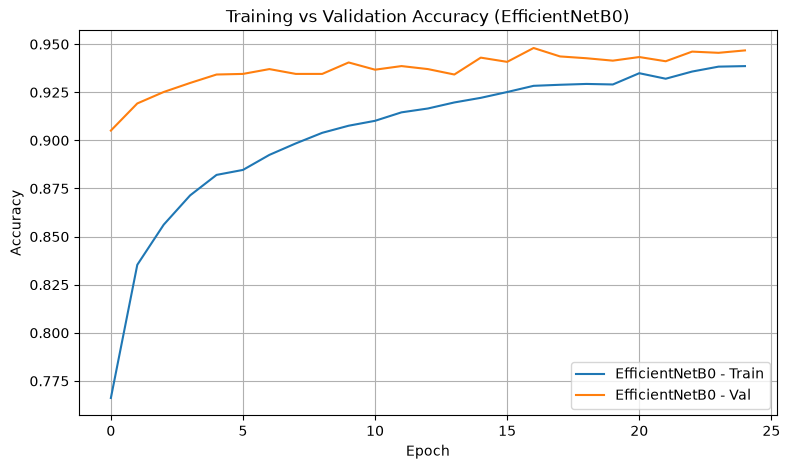

In [22]:
plt.figure(figsize=(9,5))
plt.plot(history_efficientnet.history["accuracy"], label="EfficientNetB0 - Train")
plt.plot(history_efficientnet.history["val_accuracy"], label="EfficientNetB0 - Val")

plt.title("Training vs Validation Accuracy (EfficientNetB0)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

### **16.2 GRAFIK LOSS**

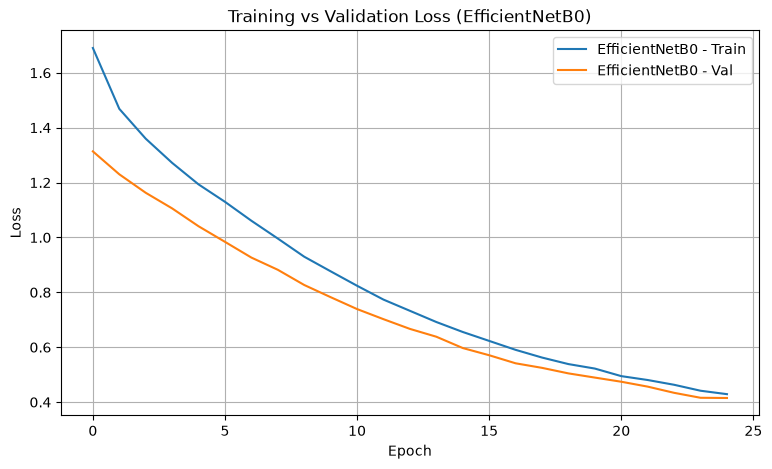

In [23]:
plt.figure(figsize=(9,5))
plt.plot(history_efficientnet.history["loss"], label="EfficientNetB0 - Train")
plt.plot(history_efficientnet.history["val_loss"], label="EfficientNetB0 - Val")

plt.title("Training vs Validation Loss (EfficientNetB0)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


## **17. FINE TUNING**

Membuka sebagian besar layer teratas dari masing-masing base model agar fitur yang lebih spesifik terhadap gambar sampah bisa ikut disesuaikan, dengan learning rate yang jauh lebih kecil supaya bobot pretrained ImageNet tidak rusak.

In [24]:
# EfficientNetB0: buka 30 layer terakhir (arsitekturnya lebih dalam per blok, jadi jumlah layer dibuka lebih sedikit)
base_efficientnet.trainable = True
for layer in base_efficientnet.layers[:-30]:
    layer.trainable = False

model_efficientnet.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### 17.1 Training Lanjutan (Fine-Tuning) — EfficientNetB0

In [25]:
history_efficientnet_finetune = model_efficientnet.fit(
    train_dataset_balanced,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_dataset,
    epochs=25,
    callbacks=callbacks_efficientnet
)

Epoch 1/25


I0000 00:00:1783299774.505394  104093 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_169581__.300


796/796 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.8788 - loss: 0.5848 - val_accuracy: 0.9277 - val_loss: 0.4605 - learning_rate: 5.0000e-06
Epoch 2/25
796/796 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.8943 - loss: 0.5490 - val_accuracy: 0.9333 - val_loss: 0.4462 - learning_rate: 5.0000e-06
Epoch 3/25
796/796 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.9011 - loss: 0.5290 - val_accuracy: 0.9377 - val_loss: 0.4331 - learning_rate: 5.0000e-06
Epoch 4/25
796/796 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.9033 - loss: 0.5097 - val_accuracy: 0.9396 - val_loss: 0.4269 - learning_rate: 5.0000e-06
Epoch 5/25
796/796 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.9080 - loss: 0.4948 - val_accuracy: 0.9399 - val_loss: 0.4218 - learning_rate: 5.0000e-06
Epoch 6/25
796/796 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.9108 - loss: 0.4861 - val_accuracy: 0.9424 - val_loss: 0.4175 - learning_rate: 5.0000e-06
Epoch 7/25
796/796 ━━━━━━━━━━━━━━━━━━━━ 37s 46ms/step - accurac

W0000 00:00:1783300117.929749  106760 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 1199360 bytes after encountering the first element of size 1199360 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


182/796 ━━━━━━━━━━━━━━━━━━━━ 26s 44ms/step - accuracy: 0.9126 - loss: 0.4817

...

605/796 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9419 - loss: 0.4018

W0000 00:00:1783300708.570867  106760 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 1202176 bytes after encountering the first element of size 1202176 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


640/796 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9416 - loss: 0.4024

W0000 00:00:1783300710.317332  106760 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 602368 bytes after encountering the first element of size 602368 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


796/796 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - accuracy: 0.9424 - loss: 0.3983 - val_accuracy: 0.9505 - val_loss: 0.3826 - learning_rate: 5.0000e-06


## **18. EVALUASI MODEL**

Evaluasi akhir pada `test_dataset` (distribusi asli, tidak di-oversampling) untuk kedua model.

In [26]:
test_loss_efficientnet, test_acc_efficientnet = model_efficientnet.evaluate(test_dataset)
print(f"[EfficientNetB0]  Test Loss: {test_loss_efficientnet:.4f} | Test Accuracy: {test_acc_efficientnet:.4f}")


 98/100 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9432 - loss: 0.4192

E0000 00:00:1783300724.783320  104092 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.9405 - loss: 0.4274
[EfficientNetB0]  Test Loss: 0.4274 | Test Accuracy: 0.9405


## **19. CLASSIFICATION REPORT**

Precision, recall, dan F1-score per kelas untuk kedua model.

In [27]:
def evaluasi_model(model, dataset, nama_model):
    y_true, y_pred = [], []
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(predictions, axis=1))
        if len(labels.shape) == 1:
            y_true.extend(labels.numpy())
        else:
            y_true.extend(np.argmax(labels.numpy(), axis=1))

    y_true, y_pred = np.array(y_true), np.array(y_pred)
    print(f"===== Classification Report: {nama_model} =====")
    print(classification_report(y_true, y_pred, target_names=class_names))
    return y_true, y_pred

y_true_efficientnet, y_pred_efficientnet = evaluasi_model(model_efficientnet, test_dataset, "EfficientNetB0")


===== Classification Report: EfficientNetB0 =====
              precision    recall  f1-score   support

   anorganik       0.94      0.93      0.93      1215
          b3       0.89      0.96      0.92       517
     organik       0.96      0.94      0.95      1463

    accuracy                           0.94      3195
   macro avg       0.93      0.94      0.94      3195
weighted avg       0.94      0.94      0.94      3195



## **20. CONFUSION MATRIX**

Confusion matrix untuk kedua model, ditampilkan berdampingan supaya mudah dibandingkan.

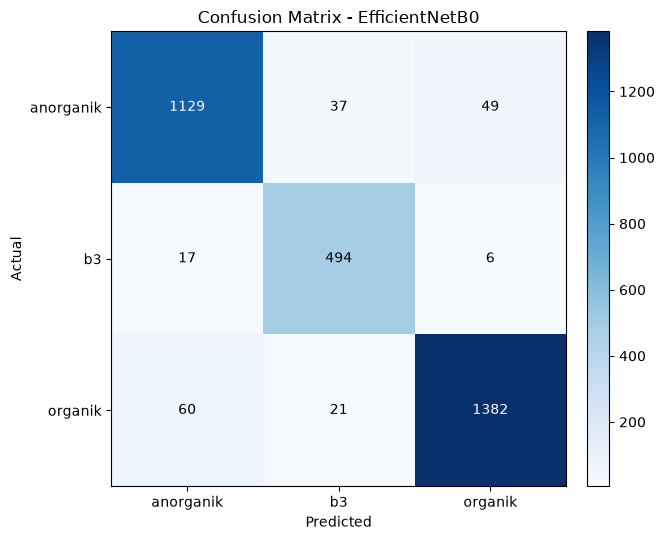

In [28]:
def plot_confusion_matrix(ax, y_true, y_pred, nama_model):
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix - {nama_model}")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    batas = cm.max() / 2
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > batas else "black"
            )
    return im

fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.5))
im = plot_confusion_matrix(ax, y_true_efficientnet, y_pred_efficientnet, "EfficientNetB0")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## **21. SIMPAN MODEL**

Kedua model yang telah dilatih dan dievaluasi disimpan dalam format `.keras`.

In [29]:
model_efficientnet.save("model_pemilah_sampah_efficientnetb0.keras")
print("Model berhasil disimpan.")


Model berhasil disimpan.


In [30]:
import json
with open("class_names.json", "w") as f:
    json.dump(class_names, f)